# ERA V5 · Session 10 — making a training loop tell the truth

A small GPT and a real loop, instrumented until every claim can be checked rather than believed.
Every number below is computed live in this notebook. The full-length run (400 steps, plus the
`torch.compile` MFU variants) is in `run.log` and `README.md`; this notebook uses fewer steps.

## Setup

In [1]:
import os, sys
if not os.path.exists('training_loop.py'):          # on Colab: fetch the code
    !pip -q install tiktoken
    !git clone -q https://github.com/sandeepkunkunuru/era-v5.git 2>/dev/null || true
    os.chdir('era-v5/session-10-training-loop')
sys.path.insert(0, os.getcwd())
import torch
import training_loop as H
H.FIGDIR = H.HERE / 'figures' / 'notebook'   # keep the full run's figures untouched
print('torch', torch.__version__, '| device', H.DEV,
      '|', torch.cuda.get_device_name() if torch.cuda.is_available() else 'cpu')
train_ids, val = H.token_splits()
print(f'{len(train_ids):,} train tokens, {len(val):,} validation tokens')

torch 2.12.1+cu130 | device cuda | NVIDIA GeForce RTX 4050 Laptop GPU
304,222 train tokens, 33,803 validation tokens


## 1. Every tensor shape in one step, and what each dimension means

Block 0 is unrolled by hand, attention included, and asserted equal to the module's output.

In [2]:
r1 = H.req1(train_ids)

1. Every tensor shape in one training step


  B=4 sequences, T=64 positions, D=256 model width, H=4 heads, Dh=64, V=50257


  idx                                (4, 64)                [B=4 sequences, T=64 positions] token ids


  targets                            (4, 64)                [B, T] the id that should come next at each position


  tok_emb = wte[idx]                 (4, 64, 256)           [B, T, D=256] one D-vector per token (a row lookup, no FLOPs)


...

  optimizer.step(): AdamW keeps two tensors per weight, each the weight's shape


  exp_avg (m), qkv.weight            (768, 256)             [3D, D] running mean of the gradient


  exp_avg_sq (v), qkv.weight         (768, 256)             [3D, D] running mean of the squared gradient


  zero_grad(set_to_none=True): qkv.weight.grad is now None


  parameters: 15,915,520 total, 3,016,960 outside the embeddings


## 2. One gradient, verified by hand

Nudge one weight, measure the loss, compare the slope with `backward()`. The first attempt uses the
model as Session 9 left it and does **not** agree — the cell explains why, then checks again.

In [3]:
r2 = H.req2(train_ids)

2. One gradient, verified by hand


  first attempt, model as in Session 9: fp64 model, central difference, eps 1e-6


    backward() +0.004259130001   nudge +0.003061712661   relative error 2.81e-01  <- they should agree to ~1e-9


  they do not. The error grows as eps shrinks, even in fp64 -- the signature of lost precision.


  cause: RMSNorm computed x.float(). For bf16 that is an upcast; for an fp64 model it is a silent


...

     1e-05 |     3.23e-09     4.62e-07 |     1.39e-01     2.85e-01


     1e-06 |     1.22e-07     8.66e-08 |     3.16e+00     1.78e+00


     1e-07 |     3.01e-06     3.01e-06 |     3.18e+01     2.90e+01


     1e-08 |     9.51e-06     9.51e-06 |     9.14e+01     9.83e+01


  fp32 is best at eps=1e-01 (7.6e-07); smaller nudges get worse, because the loss change drops below fp32's ~7 digits and the difference is mostly rounding


## 3. Gradient accumulation, broken on purpose

Micro-batches of unequal length. Correct: sum of token losses over all tokens. Buggy: average of the
micro-batch averages. Same initialisation, same data.

3. Gradient accumulation, broken on purpose


  4 micro-batches of 8 sequences per step; each micro-batch keeps 8, 16, 32, 64 or 128 of its 128


  positions in the loss (the rest are padding). Same init, same data order, two ways to combine:


    correct : sum every token's loss, divide by all valid tokens in the step


    buggy   : average each micro-batch, then average the averages


...

       0   10.4350   10.4384 |  10.478  10.460 |  10.425  10.435


     100    5.9924    5.9712 |   6.076   6.043 |   5.922   5.899


     149    5.7587    5.7736 |   5.808   5.797 |   5.692   5.715


  control, all micro-batches full length: losses 10.848073 vs 10.848073 (diff 0.0e+00), gradients differ by 0.0e+00 relative


  -> the bug is invisible whenever the token counts are equal, which is exactly how it hid.


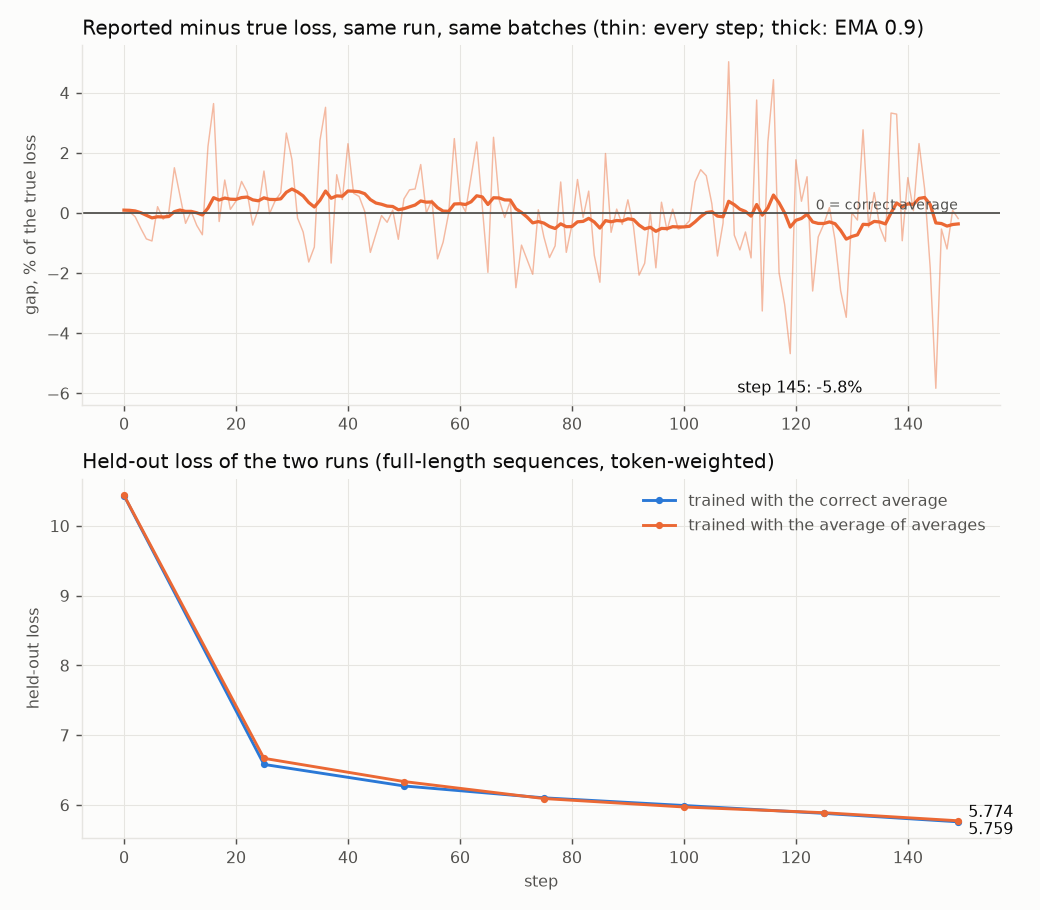

In [4]:
r3 = H.req3(train_ids, val, steps=150)
from IPython.display import Image, display
display(Image(filename=r3['figure']))

## 4. The grad norm every step — and a step where it moved before the loss

4. The grad norm, every step -- and a step where it moved first


  rule: grad norm >= 4 robust-sigma ABOVE its last 20 steps while the loss is < 2


        (still quiet), then the loss rises >= 3 robust-sigma within 10 steps.


        First 50 steps skipped. Full-length batches, so per-step loss noise is not batch shape.


  lr 1e-3, clip 1.0 (the normal setting)   final loss 5.164  max grad norm     5.52  grad-norm spikes   9  lead events 2


...

    step   97  grad norm    0.529  loss 5.8448


    step   98  grad norm    0.905  loss 6.1118   <- loss moves


    step   99  grad norm    0.603  loss 5.8359


    step  100  grad norm    0.813  loss 5.6836


  is it more than chance? P(loss spike within 10 steps | grad-norm spike) = 0.22, against 0.05 for any 10-step window


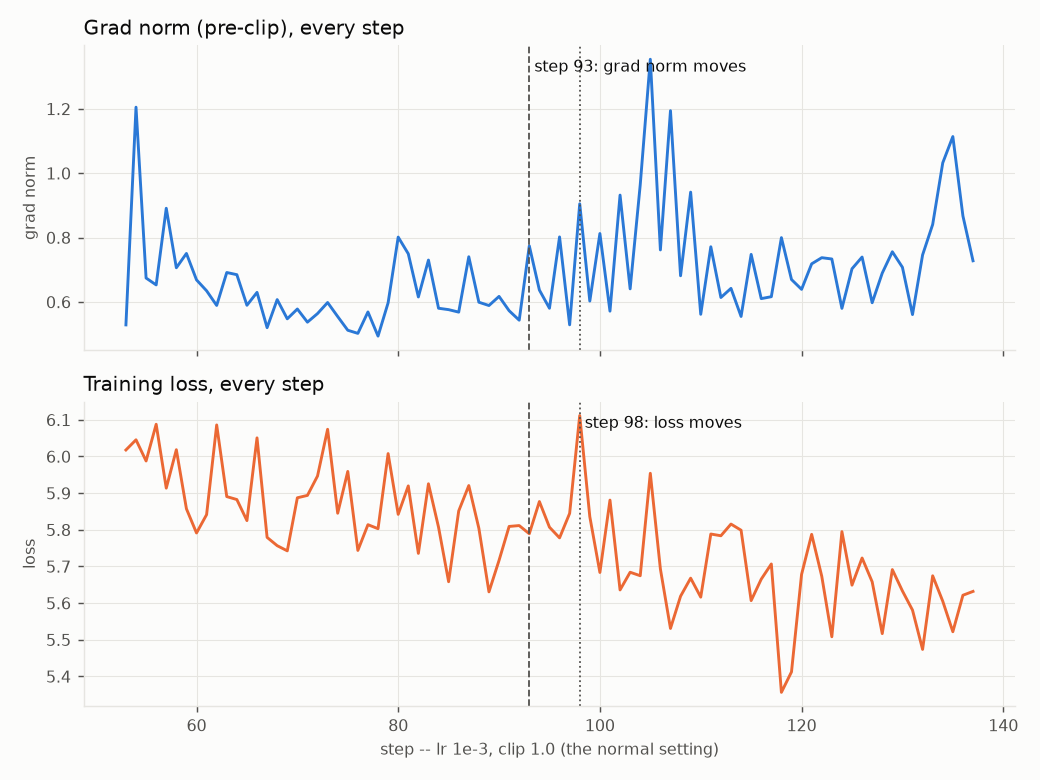

In [5]:
r4 = H.req4(train_ids, steps=250)
if r4['found']: display(Image(filename=r4['figure']))

## 5. MFU

Measured against this GPU's own bf16 matmul peak. `quick=True` skips the `torch.compile` variants;
the full table, including the 4x wider model, is in `README.md`.

In [6]:
r5 = H.req5(train_ids, quick=True)

5. MFU, measured honestly


  NVIDIA GeForce RTX 4050 Laptop GPU


  measured peak, one 8192^3 matmul: bf16 21.6 TFLOP/s, fp32 5.3 TFLOP/s


  every MFU below divides by the bf16 figure: a laptop part's datasheet peak depends on its power


  limit, so the denominator is what this card actually sustains on the friendliest workload there is


...

    matmul kernels                          27.3%


    optimizer + grad clipping                9.2%


    attention kernels                        0.9%


    embedding lookup / scatter               0.2%


USDT:2026-09-19 12:59:49 3698429:3698429 ActivityProfilerController.cpp:455] profiler_stop


## 6. 0.1 in fp32, bf16 and fp8 E4M3, bit by bit

Exact arithmetic, round to nearest even, then checked against the bits the real formats produce.

In [7]:
r6 = H.req6()

6. 0.1 in fp32, bf16 and fp8 E4M3, by hand


  0.1 = 1.6 x 2^-4, so every format stores exponent -4 and has to approximate the 0.6.


  0.6 in binary is 0.1001 1001 1001 ... -- it repeats forever, so every format must round.


  fp32: 1 sign + 8 exponent + 23 mantissa, bias 127


    exponent field = -4 + 127 = 123 = 01111011


...

    bits  0 0011 101   (0x1D)


    value (1 + 5/2^3) x 2^-4 = 0.1015625   error 1.562%


  fp32      by hand 00111101110011001100110011001101  torch 00111101110011001100110011001101  MATCH


  bf16      by hand 0011110111001101  torch 0011110111001101  MATCH


  fp8 E4M3  by hand 00011101  torch 00011101  MATCH
